In [18]:
import pandas as pd

### Load Data ######################################################################################
clinical_df = pd.read_csv(
    "../ucec_tcga_pan_can_atlas_2018/data_clinical_patient.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

status_df = pd.read_csv(
    "../ucec_tcga_pan_can_atlas_2018/data_timeline_status.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

treatment_df = pd.read_csv(
    "../ucec_tcga_pan_can_atlas_2018/data_timeline_treatment.txt",
    sep="\t",
    comment="#",   # skip header comments if present
    low_memory=False
)

# 1) Robustly get the STATUS column even if name has weird case/whitespace
col = None
for c in status_df.columns:
    if c.strip().lower() == "status":
        col = c
        break
if col is None:
    raise KeyError("No column named 'STATUS' (case-insensitive) found in status_df. Columns: " + ", ".join(status_df.columns))

# Print counts including NaN
print("\nCounts including NaN:")
print(status_df[col].value_counts(dropna=False))

# Replace with the actual column name if it's different (e.g., "PATIENT_ID", "CASE_ID", "bcr_patient_barcode")
patient_col = None
for c in status_df.columns:
    if c.strip().lower() in ["patient_id"]:
        patient_col = c
        break

if patient_col is None:
    raise KeyError("No patient ID column found in status_df. Columns: " + ", ".join(status_df.columns))

unique_patient_count = status_df[patient_col].nunique()
print("\nNumber of unique patients:", unique_patient_count, "\n")
print(clinical_df["DFS_STATUS"].value_counts(dropna=False))



Counts including NaN:
STATUS
Initial Diagnosis          523
Last Follow Up             441
DECEASED                    87
Metastatic                  27
Locoregional Recurrence     24
New Primary Tumor           11
Last Known Alive            11
Locoregional Disease        11
Distant Metastasis          10
Name: count, dtype: int64

Number of unique patients: 528 

DFS_STATUS
0:DiseaseFree            359
NaN                      115
1:Recurred/Progressed     55
Name: count, dtype: int64


In [19]:
# This cell is my way of ensuring that my understanding of the events that should mark
# a patient as having recurrence are not incorrect.

############################################
# 1. REGIMEN_INDICATION == "Recurrence"
############################################

recurrence_patients = (
    treatment_df[treatment_df["REGIMEN_INDICATION"] == "Recurrence"]["PATIENT_ID"]
    .unique()
)

dfs_recurrence = clinical_df.loc[
    clinical_df["PATIENT_ID"].isin(recurrence_patients), 
    "DFS_STATUS"
]

print("=== DFS_STATUS for REGIMEN_INDICATION = Recurrence ===")
print(dfs_recurrence.value_counts(dropna=False), "\n")

############################################
# 2. ANATOMIC_TREATMENT_SITE in target set
############################################

target_sites = {"Local Recurrence", "Distant Recurrence"}

anat_patients = (
    treatment_df[treatment_df["ANATOMIC_TREATMENT_SITE"].isin(target_sites)]["PATIENT_ID"]
    .unique()
)

dfs_anatomical = clinical_df.loc[
    clinical_df["PATIENT_ID"].isin(anat_patients),
    "DFS_STATUS"
]

print("=== DFS_STATUS for ANATOMIC_TREATMENT_SITE in", target_sites, "===")
print(dfs_anatomical.value_counts(dropna=False))

############################################
# 3. STATUS in recurrence_events
############################################

recurrence_events = {"Locoregional Recurrence", "Distant Metastasis", "Metastatic"}

patients_with_recurrence_status = (
    status_df[status_df["STATUS"].isin(recurrence_events)]["PATIENT_ID"]
    .unique()
)

dfs_for_status_recurrence = clinical_df.loc[
    clinical_df["PATIENT_ID"].isin(patients_with_recurrence_status),
    "DFS_STATUS"
]

print("=== DFS_STATUS for STATUS in recurrence_events ===")
print(dfs_for_status_recurrence.value_counts(dropna=False))


=== DFS_STATUS for REGIMEN_INDICATION = Recurrence ===
DFS_STATUS
1:Recurred/Progressed    15
NaN                      14
Name: count, dtype: int64 

=== DFS_STATUS for ANATOMIC_TREATMENT_SITE in {'Distant Recurrence', 'Local Recurrence'} ===
DFS_STATUS
1:Recurred/Progressed    10
NaN                       7
0:DiseaseFree             1
Name: count, dtype: int64
=== DFS_STATUS for STATUS in recurrence_events ===
DFS_STATUS
1:Recurred/Progressed    37
NaN                      24
Name: count, dtype: int64


In [20]:
import pandas as pd
import numpy as np

def label_patients_with_stats(status_df, treatment_df=None, clinical_df=None, min_followup_days=1095):
    '''
    Rules:
    1. Positive for recurrence (1) if:
       - STATUS in status_df contains any of:
         "Locoregional Recurrence", "Distant Metastasis", "Metastatic"
       - OR treatment_df contains:
         ANATOMIC_TREATMENT_SITE in ["Local Recurrence", "Distant Recurrence"]
         or REGIMEN_INDICATION == "Recurrence"
       - Use START_DATE from the corresponding row as RECURRENCE_DATE.
    2. No recurrence (0) if:
       - STATUS does NOT contain:
         "Locoregional Recurrence", "Distant Metastasis", "Metastatic",
         "New Primary Tumor", "Locoregional Disease", "DECEASED"
       - AND Last Follow Up row exists with START_DATE >= min_followup_days
       - AND (PRIMARY_THERAPY_OUTCOME_SUCCESS == "Complete Remission/Response"
         OR (NaN and TUMOR_STATUS == "tumor_free"))
    2. Verify DFS_STATUS in clinical_df:
       - If patient is labeled 1 but DFS_STATUS == "0:DiseaseFree", label NaN.
       - If patient is labeled 0 but DFS_STATUS == "1:Recurred/Progressed", label NaN.

    4. Otherwise label as NaN.
    
    Returns
    -------
    labels_df : pd.DataFrame
        DataFrame with one row per patient containing:
            - PATIENT_ID
            - LABEL (1 = recurrence, 0 = no recurrence, NaN = inconclusive)
            - FOLLOW_UP_DAYS
            - RECURRENCE_DATE
            - RECURRENCE_TYPE
            - SOURCE (origin of the label or reason for exclusion)

    stats : dict
        Dictionary of counts summarizing labeling:
            - recurrence_from_status
            - recurrence_from_treatment
            - no_recur_CRR
            - no_recur_tumor_free_fallback
            - excluded_progression_events
            - excluded_not_complete_remission
            - excluded_no_last_followup
            - excluded_short_followup
            - excluded_DFS_conflict

    exclusion_reason : dict
        Dictionary mapping patient IDs to the reason they were excluded or labeled NaN.
    """

'''
    recurrence_events = {"Locoregional Recurrence", "Distant Metastasis", "Metastatic"}
    progression_events = recurrence_events.union({"New Primary Tumor", "Locoregional Disease", "DECEASED"})
    treatment_recur_sites = {"Local Recurrence", "Distant Recurrence"}

    results = []
    stats = {
        "recurrence_from_status": 0,
        "recurrence_from_treatment": 0,
        "no_recur_CRR": 0,
        "no_recur_tumor_free_fallback": 0,
        "excluded_progression_events": 0,
        "excluded_not_complete_remission": 0,
        "excluded_no_last_followup": 0,
        "excluded_short_followup": 0,
        "excluded_DFS_conflict": 0
    }
    exclusion_reason = {}

    # Ensure all DFs have PATIENT_ID as a column
    for df_name, df in zip(["status_df", "treatment_df", "clinical_df"], [status_df, treatment_df, clinical_df]):
        if df is not None and "PATIENT_ID" not in df.columns:
            raise ValueError(f"{df_name} must contain column PATIENT_ID")

    for pid, df in status_df.groupby("PATIENT_ID"):
        df = df.sort_values("START_DATE")
        label = np.nan
        src = None
        followup_days = df["START_DATE"].max()
        rec_date = None
        rec_type = None

        # ------------------------------
        # Step 1: Recurrence via status_df
        # ------------------------------
        recur_rows = df[df["STATUS"].isin(recurrence_events)]
        if len(recur_rows) > 0:
            first = recur_rows.iloc[0]
            label = 1
            followup_days = first["START_DATE"]
            rec_date = first["START_DATE"]
            rec_type = first["STATUS"]
            src = "status_df"
            stats["recurrence_from_status"] += 1
            results.append({
                "PATIENT_ID": pid,
                "LABEL": label,
                "FOLLOW_UP_DAYS": followup_days,
                "RECURRENCE_DATE": rec_date,
                "RECURRENCE_TYPE": rec_type,
                "SOURCE": src
            })
            continue

        # ------------------------------
        # Step 1b: Recurrence via treatment_df
        # ------------------------------
        if treatment_df is not None:
            t_df = treatment_df[treatment_df["PATIENT_ID"] == pid]
            if len(t_df) > 0:
                site_recur = t_df[t_df["ANATOMIC_TREATMENT_SITE"].isin(treatment_recur_sites)]
                regimen_recur = t_df[t_df["REGIMEN_INDICATION"] == "Recurrence"]
                combined = pd.concat([site_recur.head(1), regimen_recur.head(1)])
                if len(combined) > 0:
                    first_recur = combined.sort_values("START_DATE").iloc[0]
                    label = 1
                    followup_days = first_recur["START_DATE"]
                    rec_date = first_recur["START_DATE"]
                    rec_type = (
                        f"Treatment {first_recur['ANATOMIC_TREATMENT_SITE']}"
                        if pd.notna(first_recur.get("ANATOMIC_TREATMENT_SITE"))
                        else "treatment_df"
                    )
                    src = "treatment_df"
                    stats["recurrence_from_treatment"] += 1
                    results.append({
                        "PATIENT_ID": pid,
                        "LABEL": label,
                        "FOLLOW_UP_DAYS": followup_days,
                        "RECURRENCE_DATE": rec_date,
                        "RECURRENCE_TYPE": rec_type,
                        "SOURCE": src
                    })
                    continue

        # ------------------------------
        # Step 2: Exclusions
        # ------------------------------
        if df["STATUS"].isin(progression_events).any():
            label = np.nan
            src = "excluded_progression"
            stats["excluded_progression_events"] += 1
            exclusion_reason[pid] = "progression event in STATUS"
            results.append({
                "PATIENT_ID": pid,
                "LABEL": label,
                "FOLLOW_UP_DAYS": followup_days,
                "RECURRENCE_DATE": None,
                "RECURRENCE_TYPE": None,
                "SOURCE": src
            })
            continue

        lf_rows = df[df["STATUS"] == "Last Follow Up"]
        if len(lf_rows) == 0:
            label = np.nan
            src = "excluded_no_lfu"
            stats["excluded_no_last_followup"] += 1
            exclusion_reason[pid] = "no last follow up"
            results.append({
                "PATIENT_ID": pid,
                "LABEL": label,
                "FOLLOW_UP_DAYS": followup_days,
                "RECURRENCE_DATE": None,
                "RECURRENCE_TYPE": None,
                "SOURCE": src
            })
            continue

        last_follow = lf_rows.iloc[-1]
        followup_days = last_follow["START_DATE"]
        if followup_days < min_followup_days:
            label = np.nan
            src = "excluded_short_followup"
            stats["excluded_short_followup"] += 1
            exclusion_reason[pid] = "short followup"
            results.append({
                "PATIENT_ID": pid,
                "LABEL": label,
                "FOLLOW_UP_DAYS": followup_days,
                "RECURRENCE_DATE": None,
                "RECURRENCE_TYPE": None,
                "SOURCE": src
            })
            continue

        # ------------------------------
        # Step 3: Tumor/therapy labeling
        # ------------------------------
        ptos = last_follow.get("PRIMARY_THERAPY_OUTCOME_SUCCESS", np.nan)
        tumor = last_follow.get("TUMOR_STATUS", np.nan)
        if pd.notna(ptos) and ptos == "Complete Remission/Response":
            label = 0
            src = "no_recur_CRR"
            stats["no_recur_CRR"] += 1
        elif pd.notna(ptos):
            label = np.nan
            src = "excluded_not_complete_remission"
            stats["excluded_not_complete_remission"] += 1
            exclusion_reason[pid] = "excluded_not_complete_remission"
        elif tumor == "Tumor Free":
            label = 0
            src = "no_recur_tumor_free_fallback"
            stats[src] = "no_recur_tumor_free_fallback"
        else:
            label = np.nan
            src = "excluded_not_complete_remission"
            stats["excluded_not_complete_remission"] += 1
            exclusion_reason[pid] = "excluded_not_complete_remission"


        results.append({
            "PATIENT_ID": pid,
            "LABEL": label,
            "FOLLOW_UP_DAYS": followup_days,
            "RECURRENCE_DATE": None,
            "RECURRENCE_TYPE": None,
            "SOURCE": src
        })

    # ------------------------------
    # Step 4: DFS conflict handling
    # ------------------------------
    labels_df = pd.DataFrame(results)
    if clinical_df is not None:
        merged = labels_df.merge(
            clinical_df[["PATIENT_ID", "DFS_STATUS"]],
            on="PATIENT_ID",
            how="left"
        )
        
        # Identify DFS conflicts
        conflict_mask = (
            ((merged["LABEL"] == 1) & (merged["DFS_STATUS"] == "0:DiseaseFree")) |
            ((merged["LABEL"] == 0) & (merged["DFS_STATUS"] == "1:Recurred/Progressed"))
        )
        
        # Update stats and reasons
        conflict_pids = merged.loc[conflict_mask, "PATIENT_ID"].tolist()
        for pid in conflict_pids:
            stats["excluded_DFS_conflict"] += 1
            exclusion_reason[pid] = "DFS conflict"
        
        # Instead of removing, set LABEL to NaN and SOURCE to 'DFS_conflict'
        merged.loc[conflict_mask, "LABEL"] = np.nan
        merged.loc[conflict_mask, "SOURCE"] = "DFS_conflict"
    
        labels_df = merged[labels_df.columns]

    return labels_df, stats, exclusion_reason


labels_df, stats, reasons = label_patients_with_stats(status_df, treatment_df, clinical_df, 1095)

print("Label counts:")
print(labels_df["LABEL"].value_counts(dropna=False))

print("\nBreakdown of labeling sources:")
print(labels_df["SOURCE"].value_counts())

print("\nDetailed exclusion reasons:")
(pd.Series(reasons).value_counts())

Label counts:
LABEL
NaN    311
0.0    138
1.0     79
Name: count, dtype: int64

Breakdown of labeling sources:
SOURCE
excluded_short_followup            230
no_recur_CRR                       104
status_df                           61
excluded_progression                59
no_recur_tumor_free_fallback        34
excluded_not_complete_remission     19
treatment_df                        18
DFS_conflict                         3
Name: count, dtype: int64

Detailed exclusion reasons:


short followup                     230
progression event in STATUS         59
excluded_not_complete_remission     19
DFS conflict                         3
Name: count, dtype: int64

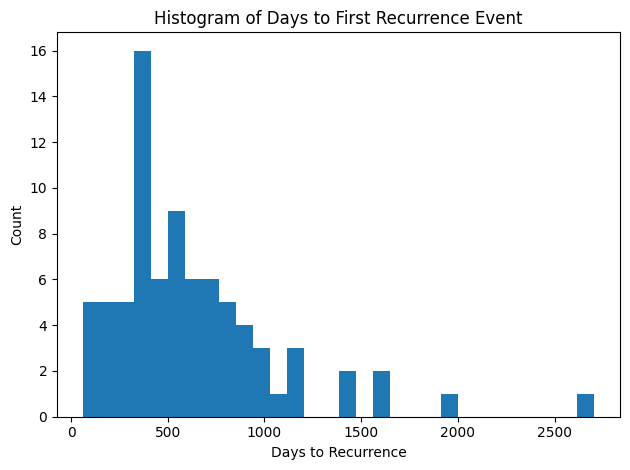

Mean recurrence time (days): 628.5375
Median recurrence time (days): 516.5


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Pull the numeric values and drop NaNs
days = labels_df["RECURRENCE_DATE"].dropna().astype(float)

plt.figure()
plt.hist(days, bins=30)   # adjust bins if needed
plt.xlabel("Days to Recurrence")
plt.ylabel("Count")
plt.title("Histogram of Days to First Recurrence Event")
plt.tight_layout()

plt.show()

# Extract numeric days and drop NaNs
days = labels_df["RECURRENCE_DATE"].dropna().astype(float)

# Compute statistics
mean_days = days.mean()
median_days = days.median()

print("Mean recurrence time (days):", mean_days)
print("Median recurrence time (days):", median_days)


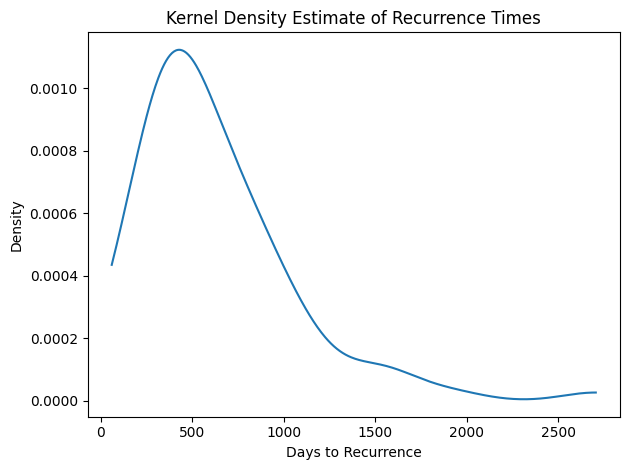

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

# Extract numeric days, drop NaNs
days = labels_df["RECURRENCE_DATE"].dropna().astype(float)

# Compute KDE
kde = gaussian_kde(days)

# Create a smooth range of x-values for plotting the curve
x_vals = np.linspace(days.min(), days.max(), 500)

# Plot KDE
plt.figure()
plt.plot(x_vals, kde(x_vals))
plt.xlabel("Days to Recurrence")
plt.ylabel("Density")
plt.title("Kernel Density Estimate of Recurrence Times")
plt.tight_layout()
plt.show()


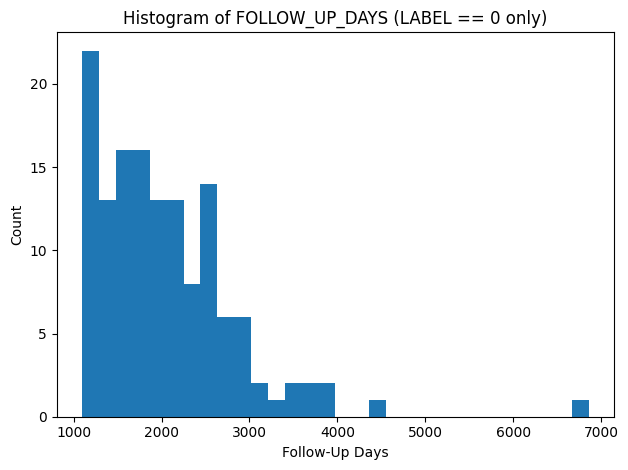

In [23]:
# Note: this graph is inherently excluding patients with less than my minimum days to last follow up
import pandas as pd
import matplotlib.pyplot as plt

# Filter to only LABEL == 0
subset = labels_df[labels_df["LABEL"] == 0]

# Extract numeric follow-up days and drop NaNs
follow_up = subset["FOLLOW_UP_DAYS"].dropna().astype(float)

plt.figure()
plt.hist(follow_up, bins=30)
plt.xlabel("Follow-Up Days")
plt.ylabel("Count")
plt.title("Histogram of FOLLOW_UP_DAYS (LABEL == 0 only)")
plt.tight_layout()
plt.show()


In [24]:
labels_series = pd.Series(
    data=labels_df["LABEL"].values,
    index=labels_df["PATIENT_ID"]
)
print(labels_series)

PATIENT_ID
TCGA-2E-A9G8    1.0
TCGA-4E-A92E    NaN
TCGA-5B-A90C    1.0
TCGA-5S-A9Q8    NaN
TCGA-A5-A0G1    NaN
               ... 
TCGA-QS-A8F1    NaN
TCGA-SJ-A6ZI    NaN
TCGA-SJ-A6ZJ    NaN
TCGA-SL-A6J9    NaN
TCGA-SL-A6JA    NaN
Length: 528, dtype: float64


In [25]:
import pandas as pd

def create_full_label_table(clinical_df, timeline_df, status_df, labels_df):
    """
    Create a merged table for all patients with recurrence info, status, and DFS months.
    Handles cases where PATIENT_ID is the index instead of a column.
    """
    # Ensure PATIENT_ID is a column in all dataframes
    for df_name, df in [("clinical_df", clinical_df), ("timeline_df", timeline_df), ("status_df", status_df)]:
        if "PATIENT_ID" not in df.columns:
            print(f"Note: 'PATIENT_ID' not found in columns of {df_name}. Using index instead.")
            df.reset_index(inplace=True)

    # Verify available columns
    expected_clinical_cols = ["PATIENT_ID", "DFS_STATUS", "DFS_MONTHS", "NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT"]
    expected_timeline_cols = ["PATIENT_ID", "ANATOMIC_TREATMENT_SITE", "REGIMEN_INDICATION"]

    missing_clinical = [c for c in expected_clinical_cols if c not in clinical_df.columns]
    missing_timeline = [c for c in expected_timeline_cols if c not in timeline_df.columns]

    if missing_clinical:
        print(f"Warning: Missing columns in clinical_df: {missing_clinical}")
    if missing_timeline:
        print(f"Warning: Missing columns in timeline_df: {missing_timeline}")

    # Select only the columns that exist
    clinical_part = clinical_df[[c for c in expected_clinical_cols if c in clinical_df.columns]].copy()
    timeline_part = timeline_df[[c for c in expected_timeline_cols if c in timeline_df.columns]].copy()

    # Merge clinical and timeline info
    merged = clinical_part.merge(timeline_part, on="PATIENT_ID", how="outer")

    # Add STATUS column if present
    if "STATUS" in status_df.columns:
        merged = merged.merge(status_df[["PATIENT_ID", "STATUS"]], on="PATIENT_ID", how="left")
    else:
        print("Warning: STATUS column not found in status_df.")

    labels_part = labels_df[[c for c in ["PATIENT_ID", "LABEL", "FOLLOW_UP_DAYS"] if c in labels_df.columns]].copy()
    merged = merged.merge(labels_part, on="PATIENT_ID", how="outer")
    
    # Sort by patient ID
    merged = merged.sort_values("PATIENT_ID").reset_index(drop=True)

    # Rename for clarity
    merged = merged.rename(columns={
        "NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT": "New_Tumor",
        "DFS_STATUS": "DFS_Status",
        "DFS_MONTHS": "DFS_Months",
        "ANATOMIC_TREATMENT_SITE": "Anatomic_Treatment",
        "REGIMEN_INDICATION": "Regimen_Indication"
    })

    return merged


def save_table_as_text(df, filename):
    """Save DataFrame as nicely formatted text file."""
    with open(filename, "w") as f:
        f.write(df.to_string(index=False))
    print(f"Saved full patient table to '{filename}'")


# Load status data
status_df = pd.read_csv(
    "../ucec_tcga_pan_can_atlas_2018/data_timeline_status.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

# Load status data
timeline_df = pd.read_csv(
    "../ucec_tcga_pan_can_atlas_2018/data_timeline_treatment.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

print(labels_df.columns)
# Create the full table
full_table = create_full_label_table(
    clinical_df=clinical_df,
    timeline_df=timeline_df,
    status_df=status_df,
    labels_df=labels_df
)

# Save as a text file
save_table_as_text(full_table, "labeling_columns_new.txt")

Index(['PATIENT_ID', 'LABEL', 'FOLLOW_UP_DAYS', 'RECURRENCE_DATE',
       'RECURRENCE_TYPE', 'SOURCE'],
      dtype='object')
Saved full patient table to 'labeling_columns_new.txt'
